# Creating Graph

In [6]:
import matplotlib.pyplot as plt
import random

In [2]:
import networkx as nx

G = nx.barabasi_albert_graph(n=100, m=2)

In [3]:
source = max(G.degree, key=lambda x: x[1])[0]

In [4]:
p = 0.3

# INITIAL NETWORK

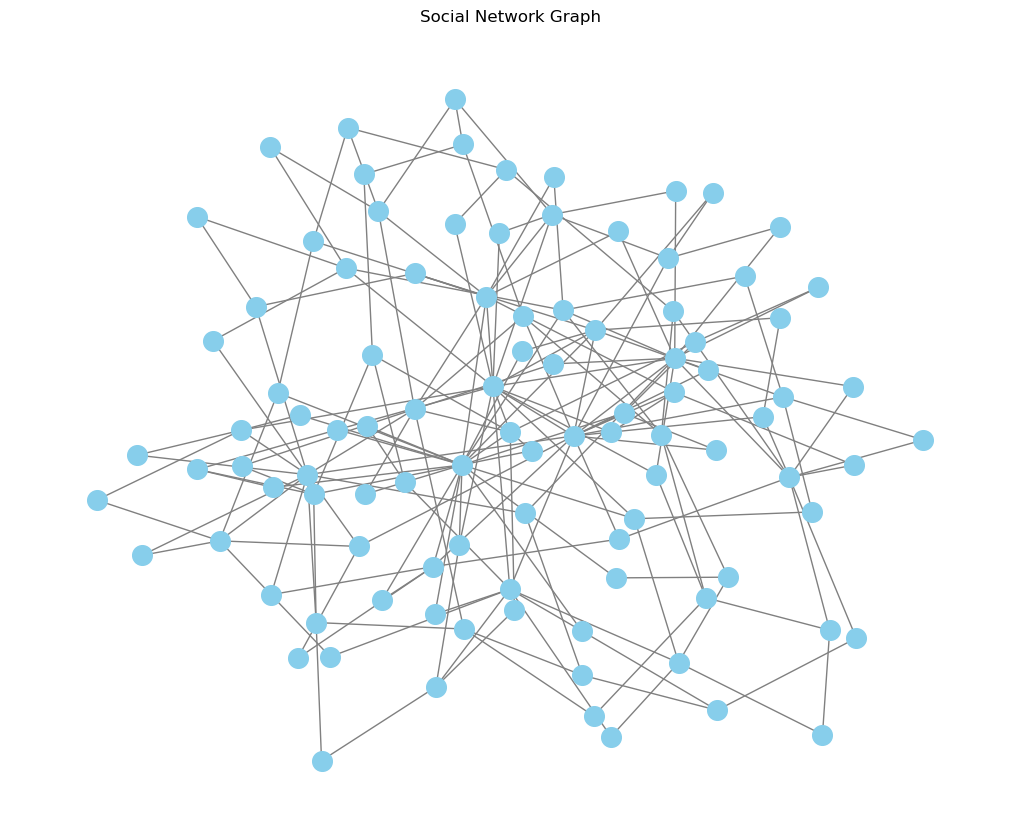

In [7]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G)

nx.draw(G,
        pos,
        node_color='skyblue',
        edge_color='gray',
        node_size=200,
        with_labels=False)

plt.title("Social Network Graph")
plt.show()

Nodes = users/accounts

Edges = social connections

Some nodes will have many connections → influencer/hub nodes

In [ ]:
# Dete

In [ ]:
# Degree of each node
degrees = dict(G.degree())

# Sort nodes by degree in descending order
hub_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)

# Print top 5 hub nodes
print("Top 5 Hub Nodes:")
for node, degree in hub_nodes[:5]:
    print("Node:", node, "Degree:", degree)

The Barabási–Albert network naturally formed hub structures, which accelerated the diffusion process during the initial stages of propagation.

# STEP-1 SPREAD

In [8]:
import random

# Initially infected node
infected = set([source])

# Step-1 spreading
new_infected = set()

for neighbor in G.neighbors(source):
    if random.random() < p:
        new_infected.add(neighbor)

infected.update(new_infected)

print("Source Node:", source)
print("Newly Infected Nodes:", new_infected)

Source Node: 1
Newly Infected Nodes: {97, 72, 75, 29, 93}


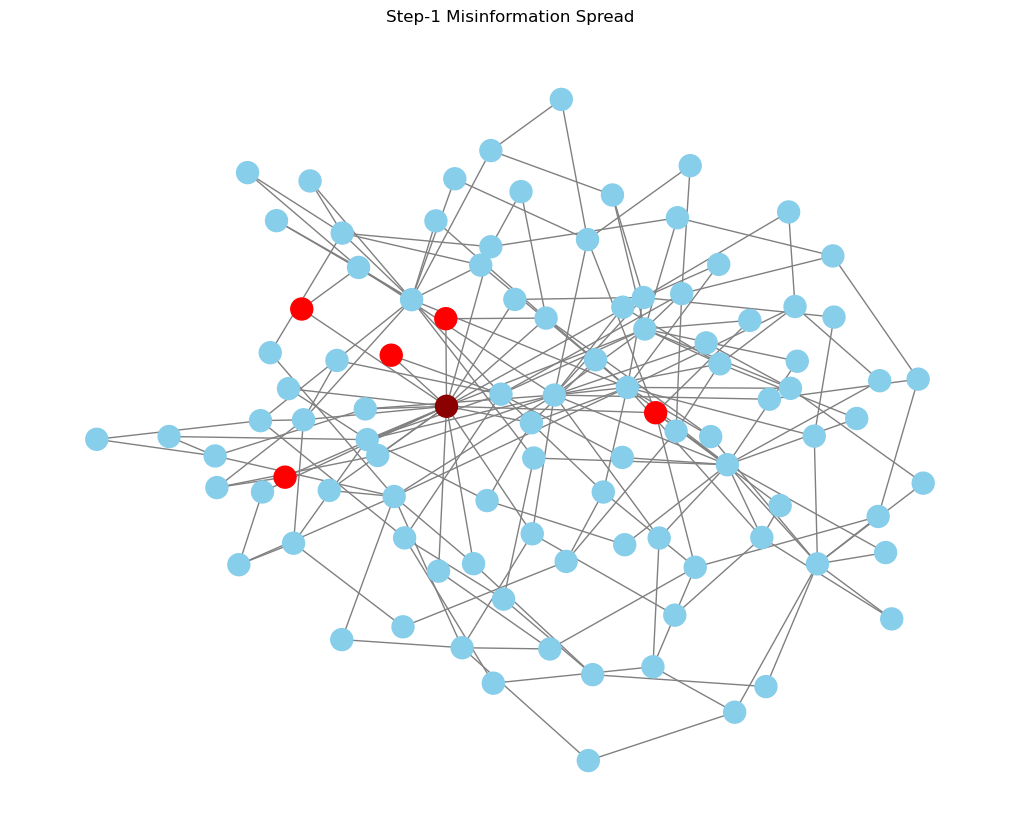

In [9]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

# Node colors
node_colors = []

for node in G.nodes():
    if node == source:
        node_colors.append("darkred")   # source node
    elif node in new_infected:
        node_colors.append("red")       # infected neighbors
    else:
        node_colors.append("skyblue")   # normal nodes

nx.draw(G,
        pos,
        node_color=node_colors,
        edge_color='gray',
        node_size=250,
        with_labels=False)

plt.title("Step-1 Misinformation Spread")
plt.show()

Color meaning

Dark red → original misinformation source

Red → newly infected nodes

Blue → unaffected users

# STEP-2 SPREAD

In [10]:
step2_infected = set()

for node in new_infected:
    
    for neighbor in G.neighbors(node):
        
        # Spread only to uninfected nodes
        if neighbor not in infected:
            
            if random.random() < p:
                step2_infected.add(neighbor)

# Update total infected nodes
infected.update(step2_infected)

print("Step-2 Newly Infected Nodes:", step2_infected)
print("Total Infected Nodes:", infected)

Step-2 Newly Infected Nodes: {11, 4}
Total Infected Nodes: {1, 97, 93, 4, 72, 11, 75, 29}


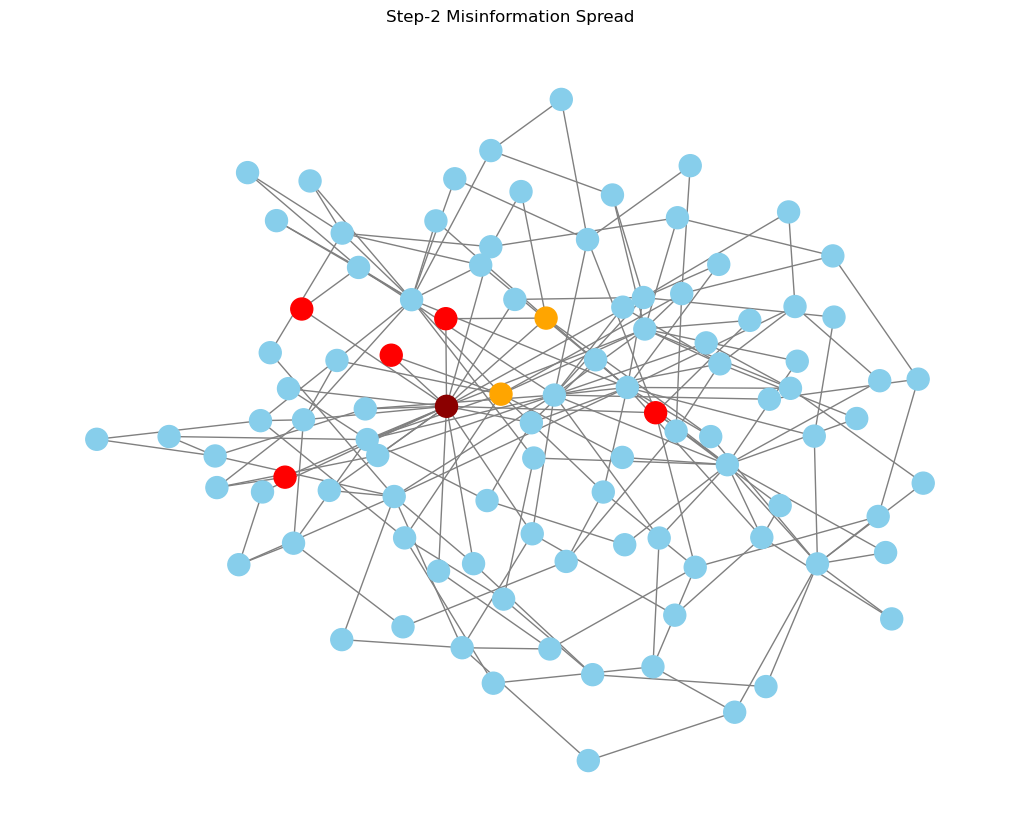

In [11]:
plt.figure(figsize=(10,8))

# Colors for nodes
node_colors = []

for node in G.nodes():
    
    if node == source:
        node_colors.append("darkred")      # original source
        
    elif node in step2_infected:
        node_colors.append("orange")       # step-2 infected
        
    elif node in infected:
        node_colors.append("red")          # previously infected
        
    else:
        node_colors.append("skyblue")      # unaffected

nx.draw(G,
        pos,
        node_color=node_colors,
        edge_color='gray',
        node_size=250,
        with_labels=False)

plt.title("Step-2 Misinformation Spread")
plt.show()

Color meaning now

Dark red → source node

Red → Step-1 infected

Orange → Step-2 infected

Blue → unaffected nodes

# FINAL SPREAD

In [12]:
active_nodes = set(step2_infected)

while active_nodes:
    
    next_infected = set()

    for node in active_nodes:
        
        for neighbor in G.neighbors(node):

            if neighbor not in infected:

                if random.random() < p:
                    next_infected.add(neighbor)

    infected.update(next_infected)

    active_nodes = next_infected

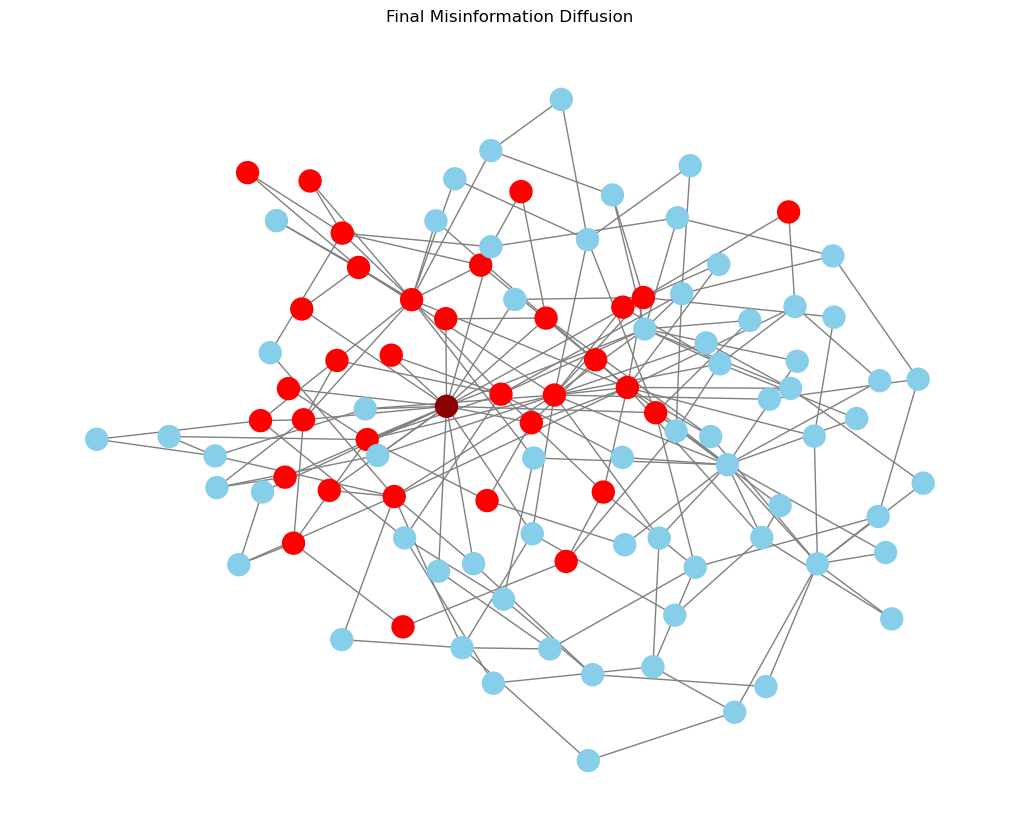

In [13]:
plt.figure(figsize=(10,8))

final_colors = []

for node in G.nodes():
    
    if node == source:
        final_colors.append("darkred")
        
    elif node in infected:
        final_colors.append("red")
        
    else:
        final_colors.append("skyblue")

nx.draw(G,
        pos,
        node_color=final_colors,
        edge_color='gray',
        node_size=250,
        with_labels=False)

plt.title("Final Misinformation Diffusion")
plt.show()

In [14]:
print("Total infected nodes:", len(infected))
print("Total nodes in network:", G.number_of_nodes())

Total infected nodes: 34
Total nodes in network: 100


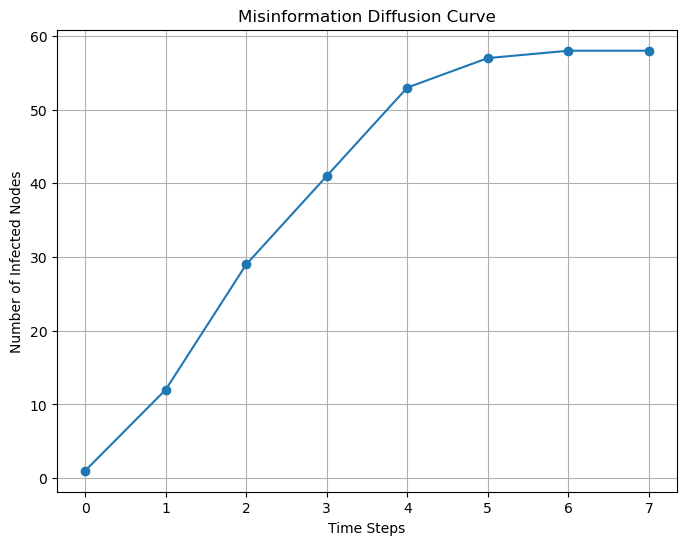

In [15]:
# Create network
G = nx.barabasi_albert_graph(n=100, m=2)

# Spread probability
p = 0.3

# Select source node (highest degree)
source = max(G.degree, key=lambda x: x[1])[0]

# Initial infected node
infected = set([source])

# Active nodes spreading misinformation
active_nodes = set([source])

# Store infection count over time
infected_count = [1]

# Time steps
time_steps = [0]

step = 0

# Diffusion process
while active_nodes:

    next_infected = set()

    for node in active_nodes:

        for neighbor in G.neighbors(node):

            if neighbor not in infected:

                if random.random() < p:
                    next_infected.add(neighbor)

    infected.update(next_infected)

    active_nodes = next_infected

    step += 1

    time_steps.append(step)
    infected_count.append(len(infected))

# Plot diffusion curve
plt.figure(figsize=(8,6))

plt.plot(time_steps,
         infected_count,
         marker='o')

plt.xlabel("Time Steps")
plt.ylabel("Number of Infected Nodes")
plt.title("Misinformation Diffusion Curve")

plt.grid(True)

plt.show()

# Detecting Hub Nodes

Top 5 Hub Nodes:
Node: 0 Degree: 27
Node: 4 Degree: 23
Node: 3 Degree: 18
Node: 5 Degree: 16
Node: 9 Degree: 11


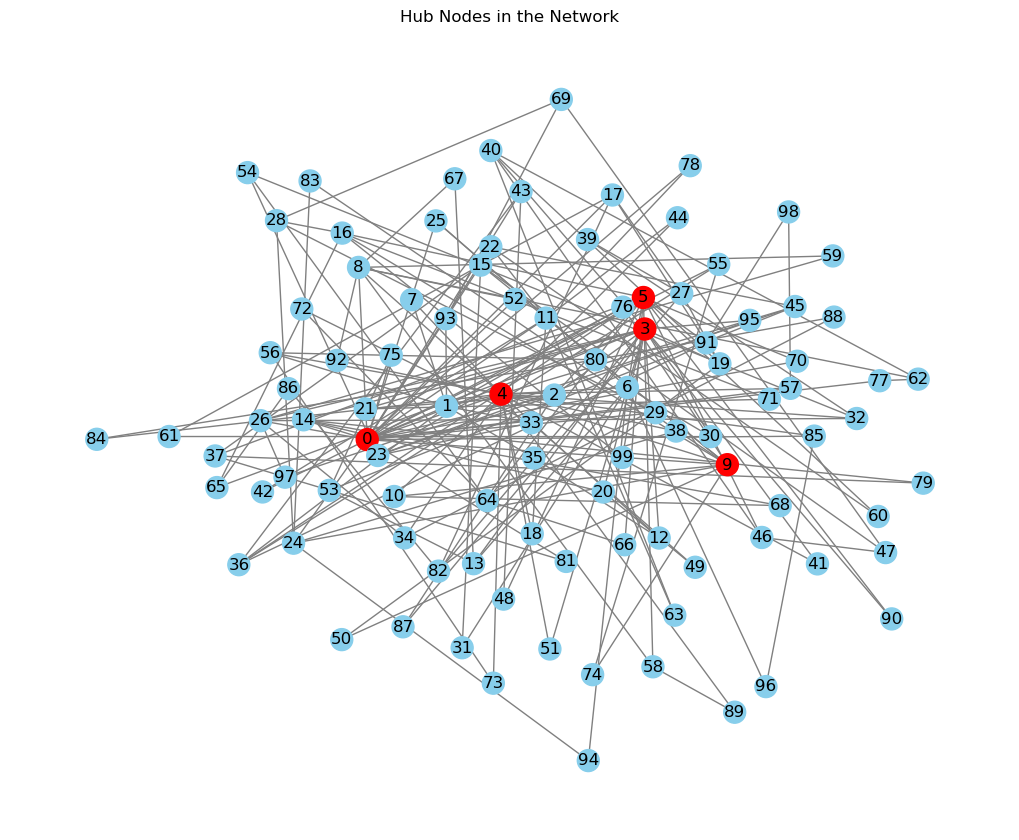

In [17]:
top_hubs = [node for node, degree in hub_nodes[:5]]

node_colors = []

for node in G.nodes():
    if node in top_hubs:
        node_colors.append("red")      # hub nodes
    else:
        node_colors.append("skyblue")  # normal nodes

plt.figure(figsize=(10,8))
nx.draw(G, pos, node_color=node_colors, edge_color="gray", node_size=250, with_labels=True)
plt.title("Hub Nodes in the Network")
plt.show()